# Exploratory Data Analysis: train.csv

This notebook explores variable distributions, missingness, target/treatment balance, and correlations in `train.csv`.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

In [3]:
df = pd.read_csv('train.csv')
df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,18.950204,10.059654,8.316096,2.039645,10.280525,3.013064,-17.602034,10.776258,3.830518,36.503025,5.300375,-0.168679,1,0,1,1
1,22.638573,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2,22.423573,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,8.754149,4.679882,10.280525,4.115453,0.294443,4.833815,3.781950,13.190056,5.300375,-0.168679,1,0,0,0
4,18.994966,10.059654,8.628266,3.907662,10.280525,4.115453,-2.411115,4.833815,3.906514,23.570168,5.300375,-0.168679,1,0,0,0


In [4]:
pd.DataFrame({
    'rows': [df.shape[0]],
    'columns': [df.shape[1]],
    'duplicate_rows': [df.duplicated().sum()]
})

,rows,columns,duplicate_rows
0,582540,16,2923


In [5]:
df.dtypes.to_frame('dtype')

,dtype
f0,float64
f1,float64
f2,float64
f3,float64
f4,float64
f5,float64
f6,float64
f7,float64
f8,float64
f9,float64


In [6]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame('missing_count')
)
missing['missing_pct'] = (missing['missing_count'] / len(df)).round(4)
missing

,missing_count,missing_pct
f0,0,0.0
f1,0,0.0
f2,0,0.0
f3,0,0.0
f4,0,0.0
f5,0,0.0
f6,0,0.0
f7,0,0.0
f8,0,0.0
f9,0,0.0


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
f0,582540.0,19.614002,5.378930,12.616365,12.616365,21.920331,24.425150,26.745253
f1,582540.0,10.069989,0.104899,10.059654,10.059654,10.059654,10.059654,15.126244
f2,582540.0,8.446414,0.299303,8.214383,8.214383,8.214383,8.722924,9.051960
f3,582540.0,4.178200,1.338211,-6.198938,4.679882,4.679882,4.679882,4.679882
f4,582540.0,10.338621,0.342623,10.280525,10.280525,10.280525,10.280525,20.227881
f5,582540.0,4.027889,0.431333,-7.676885,4.115453,4.115453,4.115453,4.115453
f6,582540.0,-4.152257,4.578295,-27.215786,-6.699321,-2.411115,0.294443,0.294443
f7,582540.0,5.105633,1.213665,4.833815,4.833815,4.833815,4.833815,11.998365
f8,582540.0,3.933637,0.056647,3.651810,3.910792,3.971858,3.971858,3.971858
f9,582540.0,16.030694,7.022742,13.190056,13.190056,13.190056,13.190056,65.754913


C:\Users\Artil\AppData\Local\Temp\ipykernel_21008\3727795570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette='Set2')
C:\Users\Artil\AppData\Local\Temp\ipykernel_21008\3727795570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette='Set2')
C:\Users\Artil\AppData\Local\Temp\ipykernel_21008\3727795570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette='Set2')
C:\Users\Artil\AppData\Local\Temp\ipykernel_21008\3727795570.py:5: FutureWarning: 

P

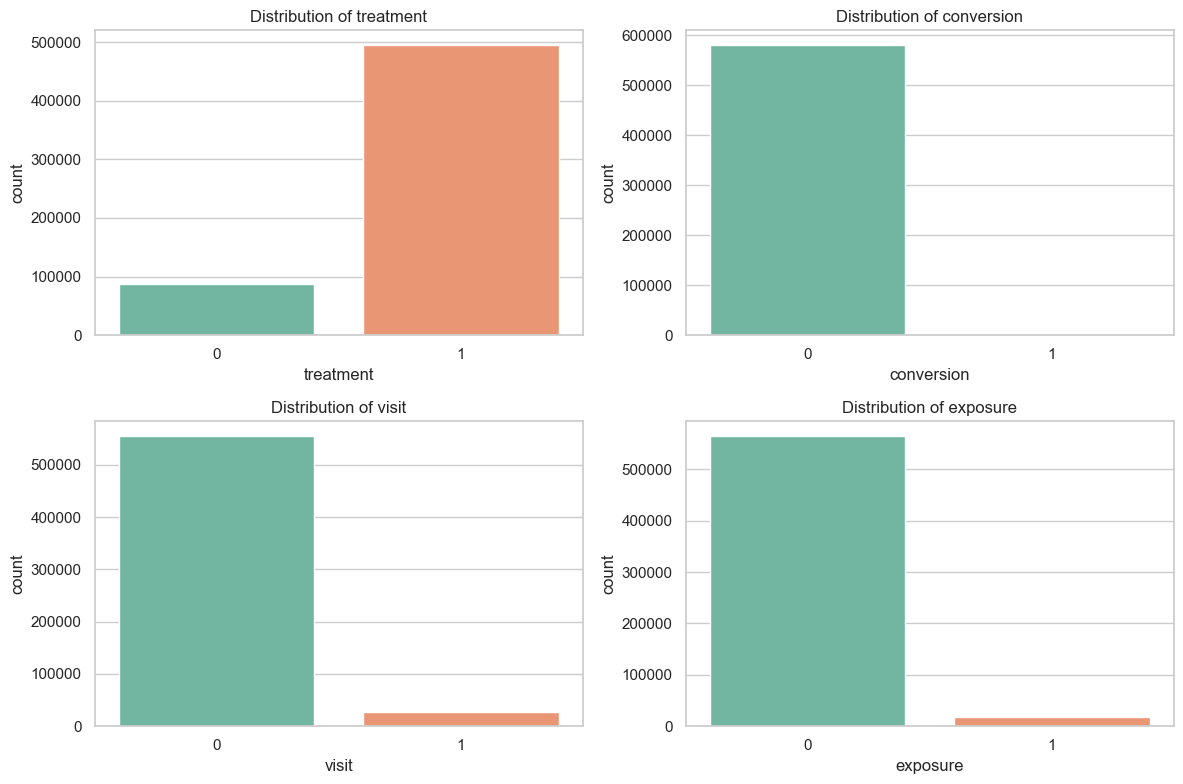

In [8]:
binary_cols = ['treatment', 'conversion', 'visit', 'exposure']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), binary_cols):
    sns.countplot(data=df, x=col, ax=ax, palette='Set2')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()

Text(0.5, 0.98, 'Distributions of Numeric Features (f0-f11)')

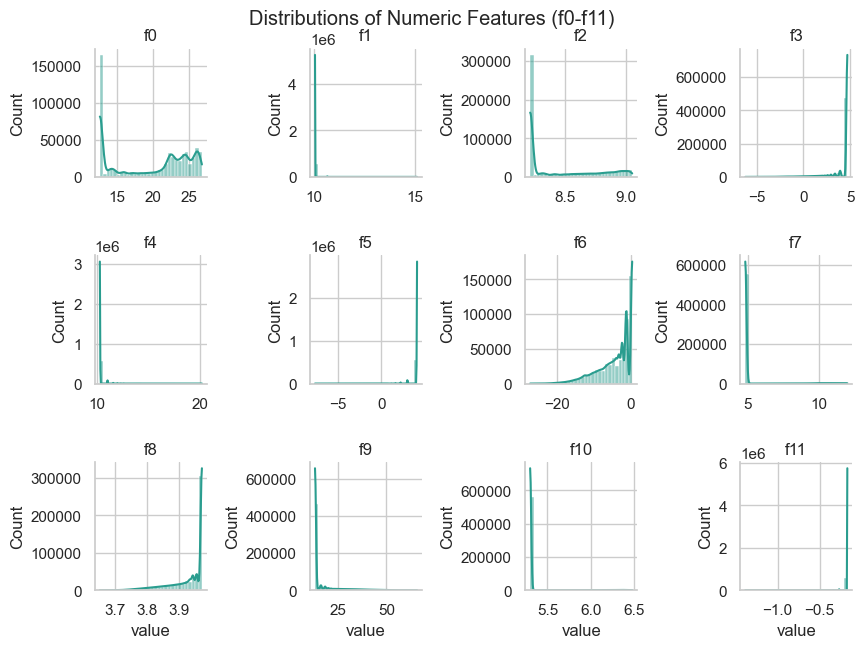

In [9]:
feature_cols = [c for c in df.columns if c.startswith('f')]
long_df = df[feature_cols].melt(var_name='feature', value_name='value')

g = sns.FacetGrid(long_df, col='feature', col_wrap=4, sharex=False, sharey=False, height=2.2)
g.map_dataframe(sns.histplot, x='value', bins=30, kde=True, color='#2A9D8F')
g.set_titles('{col_name}')
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle('Distributions of Numeric Features (f0-f11)')

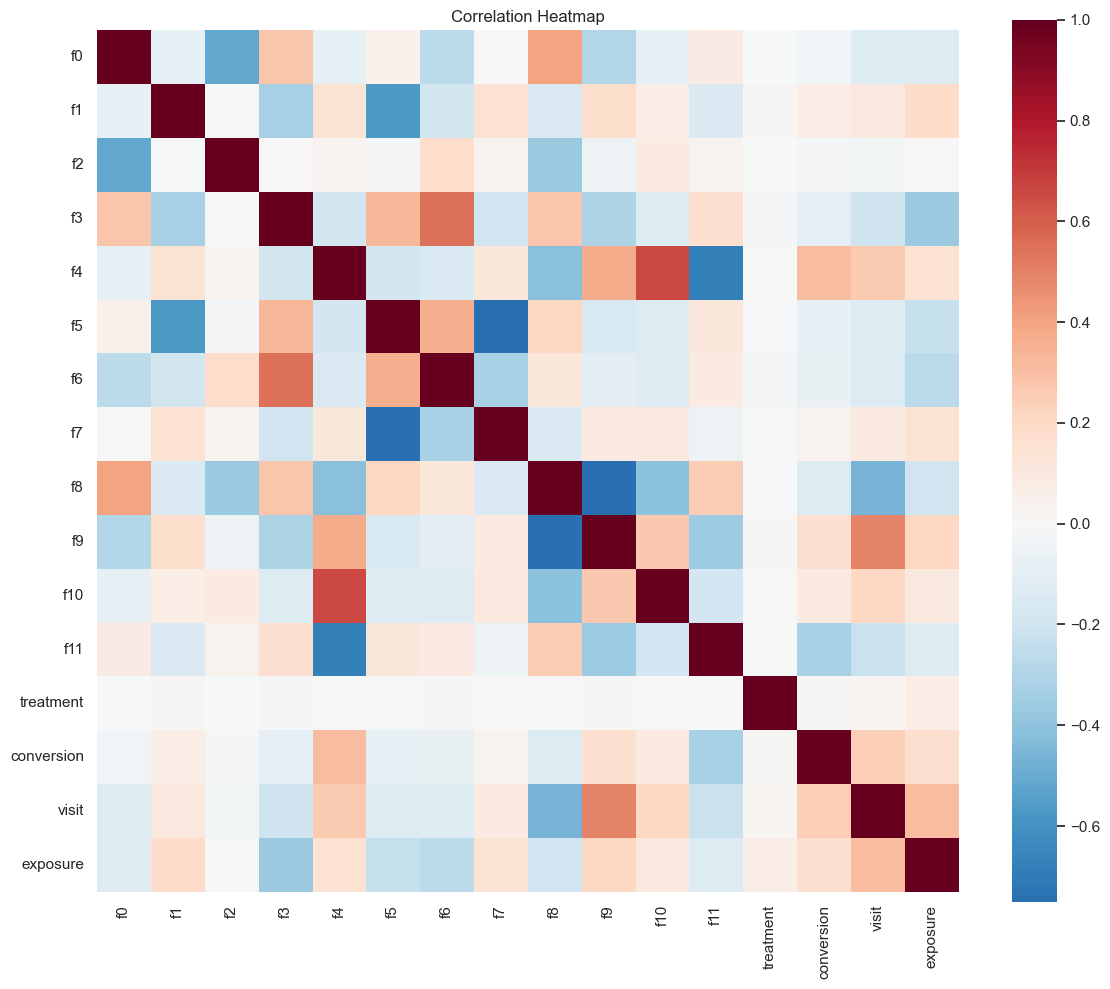

In [10]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()

In [11]:
rate_table = (
    df.groupby('treatment')[['conversion', 'visit', 'exposure']]
      .mean()
      .rename(columns={
          'conversion': 'conversion_rate',
          'visit': 'visit_rate',
          'exposure': 'exposure_rate'
      })
      .reset_index()
)
rate_table

,treatment,conversion_rate,visit_rate,exposure_rate
0,0,0.001739,0.037800,0.000000
1,1,0.003138,0.048326,0.035875


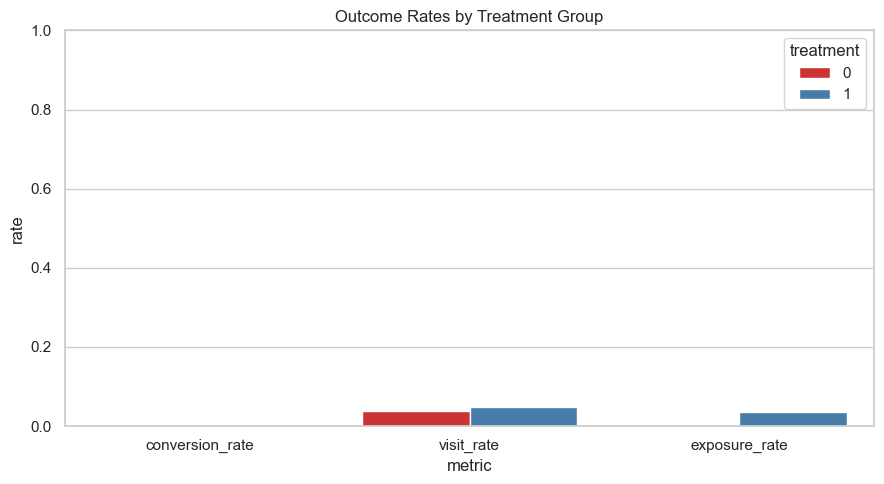

In [12]:
rate_long = rate_table.melt(id_vars='treatment', var_name='metric', value_name='rate')
plt.figure(figsize=(9, 5))
sns.barplot(data=rate_long, x='metric', y='rate', hue='treatment', palette='Set1')
plt.title('Outcome Rates by Treatment Group')
plt.ylim(0, 1)
plt.tight_layout()